# Regular vs Unstructured Grid Comparison

This notebook rebuilds both experiments from scratch under one shared set of soil and rainfall parameters.
The goal is to compare the regular and unstructured grids while keeping the physical conditions matched by construction.

## Import Required Libraries

In [1]:
from richards_model import RichardsSolver
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

## Define Soil Parameters

All soil-hydraulic parameters are stored once and reused for both grids.

In [2]:
shared_soil = {
    'alpha': 0.067 * 100,
    'n_vg': 2.0,
    'theta_r': 0.075,
    'theta_s': 0.287,
    'Ks': 100 / 100 / 3600,
    'S_s': 1e-10,
}

shared_domain = {
    'n_layers': 5,
    'dz': np.full(5, 0.04),
    'base_elevation': 10.1,
    'dx': 0.04,
}

shared_soil

{'alpha': 6.7,
 'n_vg': 2.0,
 'theta_r': 0.075,
 'theta_s': 0.287,
 'Ks': 0.0002777777777777778,
 'S_s': 1e-10}

## Define Rainfall Input

The same rainfall intensity and time stepping are used in both experiments. The targeted rainfall area is also matched: the four regular cells and the selected unstructured prism each cover the same top-surface area.

In [3]:
shared_time = {
    'dt': 864,
    'steps': 150,
}

shared_rainfall = {
    'intensity': 0.1 / 100 / 86400,
    'series': np.full(shared_time['steps'], 0.1 / 100 / 86400),
    'regular_prisms': [10, 4, 5, 11],
    'unstructured_prisms': [1],
}

shared_rainfall

{'intensity': 1.1574074074074074e-08,
 'series': array([1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.157407

## Define Regular Grid

In [4]:
def generate_regular_grid(rows=7, cols=6, dx=0.04):
    adj_prisms = {}
    A_ij = {}
    W_ij = np.zeros((rows * cols, rows * cols))
    L_ij = np.zeros((rows * cols, rows * cols))

    for r in range(rows):
        for c in range(cols):
            i = r * cols + c
            adj_prisms[i] = []
            A_ij[i] = dx * dx

            neighbors = [(r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)]
            for nr, nc in neighbors:
                if 0 <= nr < rows and 0 <= nc < cols:
                    j = nr * cols + nc
                    adj_prisms[i].append(j)
                    W_ij[i, j] = dx
                    L_ij[i, j] = dx

    W_dict = {i: list(W_ij[i]) for i in range(rows * cols)}
    L_dict = {i: list(L_ij[i]) for i in range(rows * cols)}
    return adj_prisms, A_ij, W_dict, L_dict

rows_reg, cols_reg = 7, 6
adj_reg, areas_reg, widths_reg, lengths_reg = generate_regular_grid(rows_reg, cols_reg, dx=shared_domain['dx'])
n_prisms_reg = rows_reg * cols_reg

In [6]:
reg_grid_solver = RichardsSolver(
    alpha=shared_soil['alpha'],
    n_vg=shared_soil['n_vg'],
    theta_r=np.full((n_prisms_reg, shared_domain['n_layers']), shared_soil['theta_r']),
    theta_s=np.full((n_prisms_reg, shared_domain['n_layers']), shared_soil['theta_s']),
    Ks=np.full((n_prisms_reg, shared_domain['n_layers']), shared_soil['Ks']),
    S_s=shared_soil['S_s'],
    dz=shared_domain['dz'],
    base_elevations=np.full(n_prisms_reg, shared_domain['base_elevation']),
    rainfall_intensity=shared_rainfall['intensity'],
    rainfall_prisms=shared_rainfall['regular_prisms'],
    adj_prisms=adj_reg,
    A_ij=areas_reg,
    W_ij=widths_reg,
    L_ij=lengths_reg,
)

print(f'Regular grid prisms: {n_prisms_reg}')

Regular grid prisms: 42


## Define Unstructured Grid

In [5]:
polygons_vertices = [
    ((0, 0), (1, 0), (1, 2), (0, 2)),
    ((4, 0), (6, 0), (6, 2), (4, 2)),
    ((1, 2), (4, 2), (4, 6), (2.5, 6), (2.5, 4.5), (1, 4.5)),
    ((1, 0), (3, 0), (3, 2), (1, 2)),
    ((3, 0), (4, 0), (4, 2), (3, 2)),
    ((4, 2), (6, 2), (6, 4), (4, 4)),
    ((4, 4), (6, 4), (6, 6), (4, 6)),
    ((2.5, 6), (6, 6), (6, 7), (2.5, 7)),
    ((0, 2), (1, 2), (1, 4.5), (2.5, 4.5), (2.5, 6), (0, 6)),
    ((0, 6), (2.5, 6), (2.5, 7), (0, 7)),
]

poly_objs = [Polygon(vertices) for vertices in polygons_vertices]


def generate_unstructured_domain(poly_objs, dx):
    n = len(poly_objs)
    adj_prisms = {i: [] for i in range(n)}
    A_ij = {i: poly_objs[i].area * dx**2 for i in range(n)}
    W_ij = np.zeros((n, n))
    L_ij = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            if poly_objs[i].touches(poly_objs[j]):
                intersection = poly_objs[i].intersection(poly_objs[j])
                if intersection.length > 0:
                    adj_prisms[i].append(j)
                    adj_prisms[j].append(i)
                    W_ij[i, j] = W_ij[j, i] = intersection.length * dx
                    L_ij[i, j] = L_ij[j, i] = poly_objs[i].centroid.distance(poly_objs[j].centroid) * dx

    W_dict = {i: list(W_ij[i]) for i in range(n)}
    L_dict = {i: list(L_ij[i]) for i in range(n)}
    return adj_prisms, A_ij, W_dict, L_dict

adj_uns, areas_uns, widths_uns, lengths_uns = generate_unstructured_domain(poly_objs, dx=shared_domain['dx'])
n_prisms_uns = len(poly_objs)

In [7]:
uns_grid_solver = RichardsSolver(
    alpha=shared_soil['alpha'],
    n_vg=shared_soil['n_vg'],
    theta_r=np.full((n_prisms_uns, shared_domain['n_layers']), shared_soil['theta_r']),
    theta_s=np.full((n_prisms_uns, shared_domain['n_layers']), shared_soil['theta_s']),
    Ks=np.full((n_prisms_uns, shared_domain['n_layers']), shared_soil['Ks']),
    S_s=shared_soil['S_s'],
    dz=shared_domain['dz'],
    base_elevations=np.full(n_prisms_uns, shared_domain['base_elevation']),
    rainfall_intensity=shared_rainfall['intensity'],
    rainfall_prisms=shared_rainfall['unstructured_prisms'],
    adj_prisms=adj_uns,
    A_ij=areas_uns,
    W_ij=widths_uns,
    L_ij=lengths_uns,
)

print(f'Unstructured grid prisms: {n_prisms_uns}')

Unstructured grid prisms: 10


## Validate Grid Consistency

This checks that both experiments use the same soil parameters, vertical discretization, rainfall intensity, and matched rainfall target area.

In [8]:
regular_top_area = sum(areas_reg[i] for i in shared_rainfall['regular_prisms'])
unstructured_top_area = sum(areas_uns[i] for i in shared_rainfall['unstructured_prisms'])

summary_rows = [
    ('n_layers', shared_domain['n_layers'], shared_domain['n_layers']),
    ('dz_total_m', float(np.sum(shared_domain['dz'])), float(np.sum(shared_domain['dz']))),
    ('rainfall_intensity_m_per_s', shared_rainfall['intensity'], shared_rainfall['intensity']),
    ('target_rain_area_m2', regular_top_area, unstructured_top_area),
    ('total_domain_area_m2', sum(areas_reg.values()), sum(areas_uns.values())),
    ('alpha', shared_soil['alpha'], shared_soil['alpha']),
    ('n_vg', shared_soil['n_vg'], shared_soil['n_vg']),
    ('theta_r', shared_soil['theta_r'], shared_soil['theta_r']),
    ('theta_s', shared_soil['theta_s'], shared_soil['theta_s']),
    ('Ks_m_per_s', shared_soil['Ks'], shared_soil['Ks']),
    ('S_s', shared_soil['S_s'], shared_soil['S_s']),
]

print(f"{'Quantity':<28} | {'Regular':>16} | {'Unstructured':>16}")
print('-' * 67)
for name, reg_val, uns_val in summary_rows:
    print(f"{name:<28} | {reg_val:>16.6e} | {uns_val:>16.6e}")

Quantity                     |          Regular |     Unstructured
-------------------------------------------------------------------
n_layers                     |     5.000000e+00 |     5.000000e+00
dz_total_m                   |     2.000000e-01 |     2.000000e-01
rainfall_intensity_m_per_s   |     1.157407e-08 |     1.157407e-08
target_rain_area_m2          |     6.400000e-03 |     6.400000e-03
total_domain_area_m2         |     6.720000e-02 |     6.720000e-02
alpha                        |     6.700000e+00 |     6.700000e+00
n_vg                         |     2.000000e+00 |     2.000000e+00
theta_r                      |     7.500000e-02 |     7.500000e-02
theta_s                      |     2.870000e-01 |     2.870000e-01
Ks_m_per_s                   |     2.777778e-04 |     2.777778e-04
S_s                          |     1.000000e-10 |     1.000000e-10


## Visualize Grid Comparison

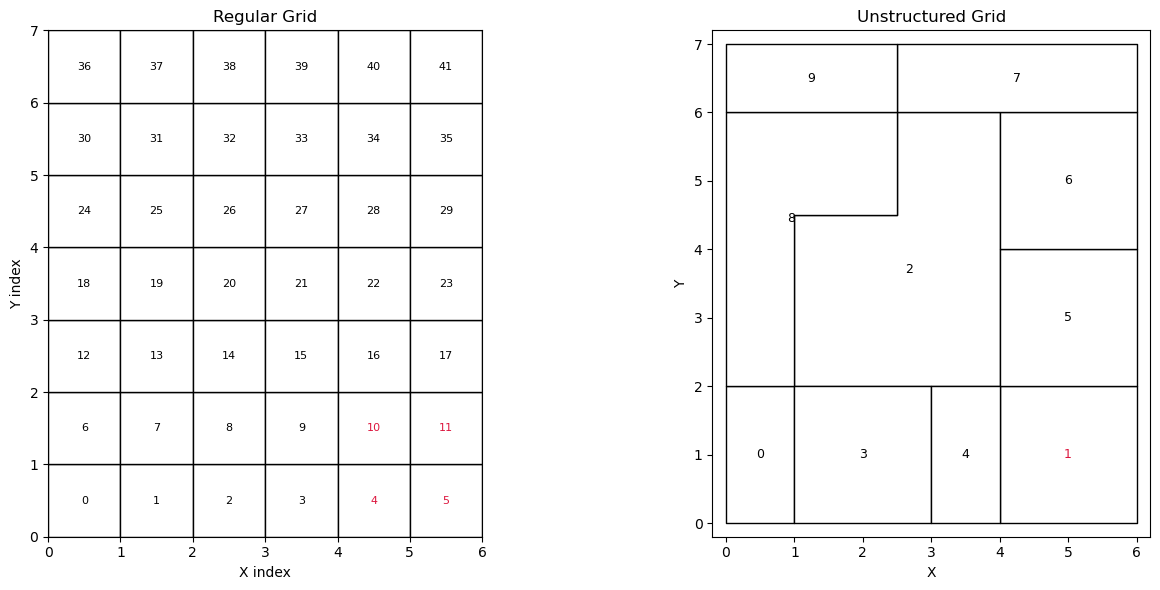

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

regular_patches = []
for r in range(rows_reg):
    for c in range(cols_reg):
        prism = r * cols_reg + c
        square = [(c, r), (c + 1, r), (c + 1, r + 1), (c, r + 1)]
        regular_patches.append(MplPolygon(square, closed=True))
        color = 'crimson' if prism in shared_rainfall['regular_prisms'] else 'black'
        ax1.text(c + 0.5, r + 0.5, str(prism), ha='center', va='center', fontsize=8, color=color)

pc_reg = PatchCollection(regular_patches, facecolor='white', edgecolor='black', linewidth=1)
ax1.add_collection(pc_reg)
ax1.set_xlim(0, cols_reg)
ax1.set_ylim(0, rows_reg)
ax1.set_aspect('equal')
ax1.set_title('Regular Grid')
ax1.set_xlabel('X index')
ax1.set_ylabel('Y index')

unstructured_patches = []
all_x = []
all_y = []
for prism, poly in enumerate(poly_objs):
    coords = np.asarray(poly.exterior.coords)
    unstructured_patches.append(MplPolygon(coords, closed=True))
    centroid = poly.centroid
    color = 'crimson' if prism in shared_rainfall['unstructured_prisms'] else 'black'
    ax2.text(centroid.x, centroid.y, str(prism), ha='center', va='center', fontsize=9, color=color)
    all_x.extend(coords[:, 0])
    all_y.extend(coords[:, 1])

pc_uns = PatchCollection(unstructured_patches, facecolor='white', edgecolor='black', linewidth=1)
ax2.add_collection(pc_uns)
ax2.set_aspect('equal')
ax2.set_title('Unstructured Grid')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_xlim(min(all_x) - 0.2, max(all_x) + 0.2)
ax2.set_ylim(min(all_y) - 0.2, max(all_y) + 0.2)

plt.tight_layout()
plt.show()

## Compare Integrated Metrics

In [10]:
def run_experiment_metrics(solver, dt, steps, h0_value=-10.0):
    h = np.full(solver.total_cells, h0_value)
    s0 = solver.calculate_storage(h)
    cumulative_inflow = 0.0
    cumulative_lateral_exchange = 0.0

    for _ in range(steps):
        h = solver.solve_step(h, dt)
        q_in = solver.get_boundary_flux_with_rain(h)
        cumulative_inflow += q_in * dt
        q_lat = solver.get_total_lateral_exchange(h)
        cumulative_lateral_exchange += q_lat * dt

    s_end = solver.calculate_storage(h)
    storage_change = s_end - s0
    mass_error = storage_change - cumulative_inflow
    rel_mass_error_pct = 100.0 * mass_error / (abs(cumulative_inflow) + 1e-30)

    return {
        'storage_initial_m3': s0,
        'storage_final_m3': s_end,
        'storage_change_m3': storage_change,
        'cumulative_inflow_m3': cumulative_inflow,
        'mass_error_m3': mass_error,
        'rel_mass_error_pct': rel_mass_error_pct,
        'cumulative_lateral_exchange_m3': cumulative_lateral_exchange,
    }


def relative_difference_pct(a, b):
    denom = max(abs(a), abs(b), 1e-30)
    return 100.0 * abs(a - b) / denom

reg_metrics = run_experiment_metrics(reg_grid_solver, shared_time['dt'], shared_time['steps'])
uns_metrics = run_experiment_metrics(uns_grid_solver, shared_time['dt'], shared_time['steps'])

metric_keys = [
    'storage_initial_m3',
    'storage_final_m3',
    'storage_change_m3',
    'cumulative_inflow_m3',
    'mass_error_m3',
    'rel_mass_error_pct',
    'cumulative_lateral_exchange_m3',
]

print(f"Comparison settings: dt={shared_time['dt']} s, steps={shared_time['steps']}")
print('=' * 102)
print(f"{'Metric':<34} | {'Regular':>20} | {'Unstructured':>20} | {'RelDiff %':>12}")
print('-' * 102)
for key in metric_keys:
    reg_val = reg_metrics[key]
    uns_val = uns_metrics[key]
    rel_diff = relative_difference_pct(reg_val, uns_val)
    print(f"{key:<34} | {reg_val:>20.6e} | {uns_val:>20.6e} | {rel_diff:>12.4f}")
print('=' * 102)

Comparison settings: dt=864 s, steps=150
Metric                             |              Regular |         Unstructured |    RelDiff %
------------------------------------------------------------------------------------------------------
storage_initial_m3                 |         1.050522e-03 |         1.050522e-03 |       0.0000
storage_final_m3                   |         1.060122e-03 |         1.060122e-03 |       0.0000
storage_change_m3                  |         9.600001e-06 |         9.600001e-06 |       0.0000
cumulative_inflow_m3               |         9.600000e-06 |         9.600000e-06 |       0.0000
mass_error_m3                      |         9.233420e-13 |         1.163162e-12 |      20.6179
rel_mass_error_pct                 |         9.618145e-06 |         1.211627e-05 |      20.6179
cumulative_lateral_exchange_m3     |         2.999240e-07 |         1.004220e-07 |      66.5175


## Compare Mass-Error Time Series

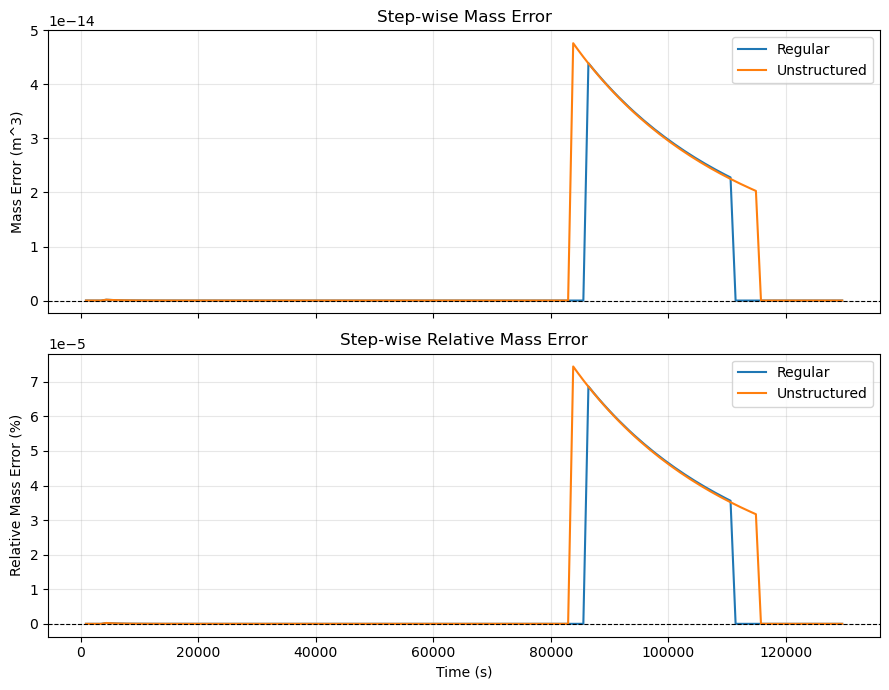

In [11]:
def mass_error_time_series(solver, dt, steps, h0_value=-10.0):
    h = np.full(solver.total_cells, h0_value)
    times = []
    step_mass_error = []
    step_rel_mass_error_pct = []

    for t in range(steps):
        s_old = solver.calculate_storage(h)
        h_next = solver.solve_step(h, dt)
        s_new = solver.calculate_storage(h_next)
        q_in = solver.get_boundary_flux_with_rain(h_next)

        expected_change = q_in * dt
        actual_change = s_new - s_old
        err = actual_change - expected_change
        rel_err = 100.0 * err / (abs(expected_change) + 1e-30)

        times.append((t + 1) * dt)
        step_mass_error.append(err)
        step_rel_mass_error_pct.append(rel_err)
        h = h_next

    return np.array(times), np.array(step_mass_error), np.array(step_rel_mass_error_pct)

tr, err_r, rel_r = mass_error_time_series(reg_grid_solver, shared_time['dt'], shared_time['steps'])
tu, err_u, rel_u = mass_error_time_series(uns_grid_solver, shared_time['dt'], shared_time['steps'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
ax1.plot(tr, err_r, label='Regular', color='tab:blue')
ax1.plot(tu, err_u, label='Unstructured', color='tab:orange')
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax1.set_ylabel('Mass Error (m^3)')
ax1.set_title('Step-wise Mass Error')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(tr, rel_r, label='Regular', color='tab:blue')
ax2.plot(tu, rel_u, label='Unstructured', color='tab:orange')
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Relative Mass Error (%)')
ax2.set_title('Step-wise Relative Mass Error')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

## Full Per-Step Budget Diagnostics

In [12]:
def _ensure_Z(solver):
    solver.Z = np.array([solver.get_z_centers(b, solver.dz) for b in solver.base_elevations])


def compute_vertical_net_flux(solver, h):
    _ensure_Z(solver)
    net = np.zeros(solver.total_cells)
    for k in range(solver.n_layers):
        for i in range(solver.n_prisms):
            idx_i = k * solver.n_prisms + i
            for direction in [-1, 1]:
                adj_k = k + direction
                if 0 <= adj_k < solver.n_layers:
                    idx_j = adj_k * solver.n_prisms + i
                    K_face = 2 / (
                        1 / solver.get_K(h[idx_i], k, i) +
                        1 / solver.get_K(h[idx_j], adj_k, i)
                    )
                    dz_dist = abs(solver.Z[i, adj_k] - solver.Z[i, k])
                    G_v = solver.A_ij[i] / dz_dist
                    total_head_grad = solver.get_total_head_gradient(
                        h[idx_i], solver.Z[i, k], h[idx_j], solver.Z[i, adj_k]
                    )
                    net[idx_i] += G_v * K_face * total_head_grad
    return net


def run_budget_diagnostics(solver, dt, steps, h0_value=-10.0):
    h = np.full(solver.total_cells, h0_value)
    _ensure_Z(solver)

    times = np.zeros(steps)
    dS = np.zeros(steps)
    q_rain_vol = np.zeros(steps)
    lat_exchange = np.zeros(steps)
    vert_net_in = np.zeros(steps)
    mass_error = np.zeros(steps)
    cum_error = np.zeros(steps)

    cumulative = 0.0
    for t in range(steps):
        s_old = solver.calculate_storage(h)
        h_next = solver.solve_step(h, dt)
        s_new = solver.calculate_storage(h_next)

        q_in = solver.get_boundary_flux_with_rain(h_next)
        q_lat = solver.get_total_lateral_exchange(h_next)
        q_vert = compute_vertical_net_flux(solver, h_next).sum()

        delta_s = s_new - s_old
        expected = q_in * dt
        err = delta_s - expected
        cumulative += err

        times[t] = (t + 1) * dt
        dS[t] = delta_s
        q_rain_vol[t] = expected
        lat_exchange[t] = q_lat * dt
        vert_net_in[t] = q_vert * dt
        mass_error[t] = err
        cum_error[t] = cumulative
        h = h_next

    return {
        'times': times,
        'dS': dS,
        'q_rain_vol': q_rain_vol,
        'lat_exchange': lat_exchange,
        'vert_net_in': vert_net_in,
        'mass_error': mass_error,
        'cum_error': cum_error,
    }

bd_r = run_budget_diagnostics(reg_grid_solver, shared_time['dt'], shared_time['steps'])
bd_u = run_budget_diagnostics(uns_grid_solver, shared_time['dt'], shared_time['steps'])

cols_def = [
    ('Time(s)', 'times', 'reg'),
    ('dS_R', 'dS', 'reg'),
    ('Qrain_R', 'q_rain_vol', 'reg'),
    ('Qlat_R', 'lat_exchange', 'reg'),
    ('Qvert_R', 'vert_net_in', 'reg'),
    ('Err_R', 'mass_error', 'reg'),
    ('CumErr_R', 'cum_error', 'reg'),
    ('dS_U', 'dS', 'uns'),
    ('Qrain_U', 'q_rain_vol', 'uns'),
    ('Qlat_U', 'lat_exchange', 'uns'),
    ('Qvert_U', 'vert_net_in', 'uns'),
    ('Err_U', 'mass_error', 'uns'),
    ('CumErr_U', 'cum_error', 'uns'),
]

width = 14
print('-' * (width * len(cols_def) + len(cols_def) - 1))
print(' | '.join(f"{label:>{width}}" for label, _, _ in cols_def))
print('-' * (width * len(cols_def) + len(cols_def) - 1))
for t in range(shared_time['steps']):
    values = []
    for _, key, which in cols_def:
        src = bd_r if which == 'reg' else bd_u
        values.append(src[key][t])
    print(' | '.join(f"{value:>{width}.4e}" for value in values))
print('-' * (width * len(cols_def) + len(cols_def) - 1))

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
       Time(s) |           dS_R |        Qrain_R |         Qlat_R |        Qvert_R |          Err_R |       CumErr_R |           dS_U |        Qrain_U |         Qlat_U |        Qvert_U |          Err_U |       CumErr_U
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    8.6400e+02 |     6.4000e-08 |     6.4000e-08 |     4.9833e-11 |     0.0000e+00 |     3.5718e-19 |     3.5718e-19 |     6.4000e-08 |     6.4000e-08 |     2.9059e-11 |    -1.3632e-27 |    -7.6498e-20 |    -7.6498e-20
    1.7280e+03 |     6.4000e-08 |     6.4000e-08 |     1.0473e-10 |    -8.1789e-27 |    -3.9796e-18 |    -3.6224e-18 |     6.4000e-08 |     6.4000e-08 |     6.1045e-11 |   

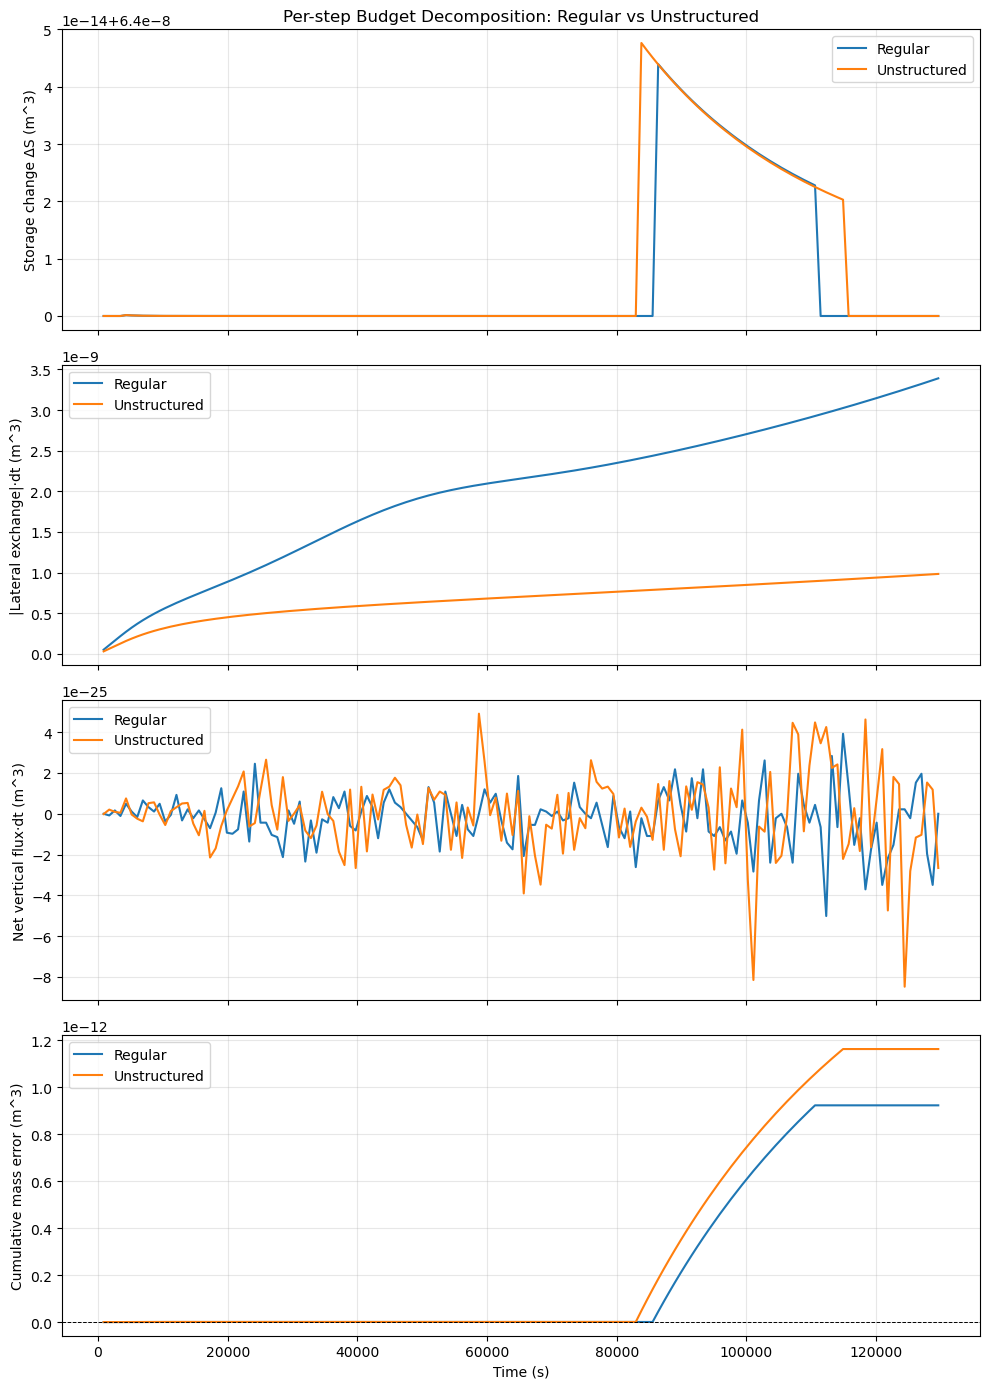

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)
plot_config = [
    ('Storage change ΔS (m^3)', 'dS', False),
    ('|Lateral exchange|·dt (m^3)', 'lat_exchange', False),
    ('Net vertical flux·dt (m^3)', 'vert_net_in', False),
    ('Cumulative mass error (m^3)', 'cum_error', True),
]

for ax, (ylabel, key, add_zero) in zip(axes, plot_config):
    ax.plot(bd_r['times'], bd_r[key], label='Regular', color='tab:blue')
    ax.plot(bd_u['times'], bd_u[key], label='Unstructured', color='tab:orange')
    if add_zero:
        ax.axhline(0, color='black', linestyle='--', linewidth=0.7)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_title('Per-step Budget Decomposition: Regular vs Unstructured')
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## Δt Refinement Study

This section repeats the same experiment with progressively smaller time steps while keeping the total simulated time fixed. It helps separate time-integration error from geometry-dependent effects.

  dt (s) |    steps |   Reg err (m3) |   Uns err (m3) |    Reg rel % |    Uns rel %
--------------------------------------------------------------------------------------
     864 |      150 |   9.233420e-13 |   1.163162e-12 | 9.618145e-06 | 1.211627e-05
     432 |      300 |   6.463480e-13 |   6.818266e-13 | 6.732792e-06 | 7.102360e-06
     216 |      600 |   2.373804e-13 |   2.419300e-13 | 2.472713e-06 | 2.520104e-06
     108 |     1200 |   7.901856e-14 |   8.052516e-14 | 8.231099e-07 | 8.388038e-07


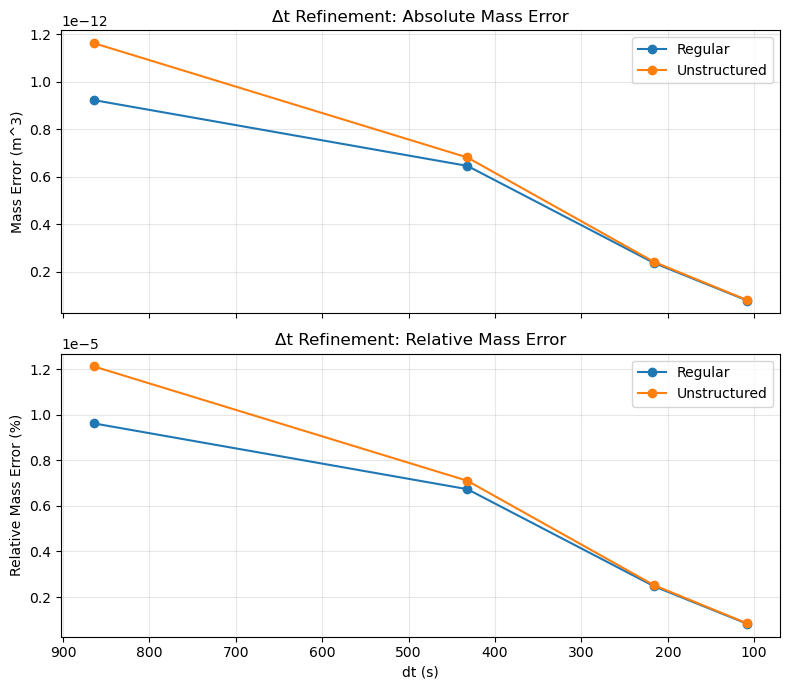

In [14]:
total_time = shared_time['dt'] * shared_time['steps']
dt_values = [864, 432, 216, 108]
refinement_results = []

for dt_value in dt_values:
    steps_value = total_time // dt_value
    if total_time % dt_value != 0:
        raise ValueError(f'dt={dt_value} does not divide total_time={total_time}')

    reg_metrics_dt = run_experiment_metrics(reg_grid_solver, dt_value, int(steps_value))
    uns_metrics_dt = run_experiment_metrics(uns_grid_solver, dt_value, int(steps_value))

    refinement_results.append({
        'dt': dt_value,
        'steps': int(steps_value),
        'reg_mass_error': reg_metrics_dt['mass_error_m3'],
        'uns_mass_error': uns_metrics_dt['mass_error_m3'],
        'reg_rel_mass_error_pct': reg_metrics_dt['rel_mass_error_pct'],
        'uns_rel_mass_error_pct': uns_metrics_dt['rel_mass_error_pct'],
        'reg_lateral_exchange': reg_metrics_dt['cumulative_lateral_exchange_m3'],
        'uns_lateral_exchange': uns_metrics_dt['cumulative_lateral_exchange_m3'],
    })

print(f"{'dt (s)':>8} | {'steps':>8} | {'Reg err (m3)':>14} | {'Uns err (m3)':>14} | {'Reg rel %':>12} | {'Uns rel %':>12}")
print('-' * 86)
for row in refinement_results:
    print(
        f"{row['dt']:>8d} | {row['steps']:>8d} | {row['reg_mass_error']:>14.6e} | "
        f"{row['uns_mass_error']:>14.6e} | {row['reg_rel_mass_error_pct']:>12.6e} | {row['uns_rel_mass_error_pct']:>12.6e}"
    )

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
ax1.plot(dt_values, [row['reg_mass_error'] for row in refinement_results], marker='o', label='Regular', color='tab:blue')
ax1.plot(dt_values, [row['uns_mass_error'] for row in refinement_results], marker='o', label='Unstructured', color='tab:orange')
ax1.set_ylabel('Mass Error (m^3)')
ax1.set_title('Δt Refinement: Absolute Mass Error')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(dt_values, [row['reg_rel_mass_error_pct'] for row in refinement_results], marker='o', label='Regular', color='tab:blue')
ax2.plot(dt_values, [row['uns_rel_mass_error_pct'] for row in refinement_results], marker='o', label='Unstructured', color='tab:orange')
ax2.set_xlabel('dt (s)')
ax2.set_ylabel('Relative Mass Error (%)')
ax2.set_title('Δt Refinement: Relative Mass Error')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.invert_xaxis()

plt.tight_layout()
plt.show()

## No-Lateral-Flow Control Case

This control removes all horizontal conductance by setting every lateral face width to zero. The result isolates purely vertical infiltration and storage dynamics on both grids.

Metric                             |       Reg full |     Reg no-lat |       Uns full |     Uns no-lat
----------------------------------------------------------------------------------------------------
storage_initial_m3                 |   1.050522e-03 |   1.050522e-03 |   1.050522e-03 |   1.050522e-03
storage_final_m3                   |   1.060122e-03 |   1.060122e-03 |   1.060122e-03 |   1.060122e-03
storage_change_m3                  |   9.600001e-06 |   9.600001e-06 |   9.600001e-06 |   9.600001e-06
cumulative_inflow_m3               |   9.600000e-06 |   9.600000e-06 |   9.600000e-06 |   9.600000e-06
mass_error_m3                      |   9.233420e-13 |   1.004198e-12 |   1.163162e-12 |   1.004200e-12
rel_mass_error_pct                 |   9.618145e-06 |   1.046039e-05 |   1.211627e-05 |   1.046041e-05
cumulative_lateral_exchange_m3     |   2.999240e-07 |   0.000000e+00 |   1.004220e-07 |   0.000000e+00


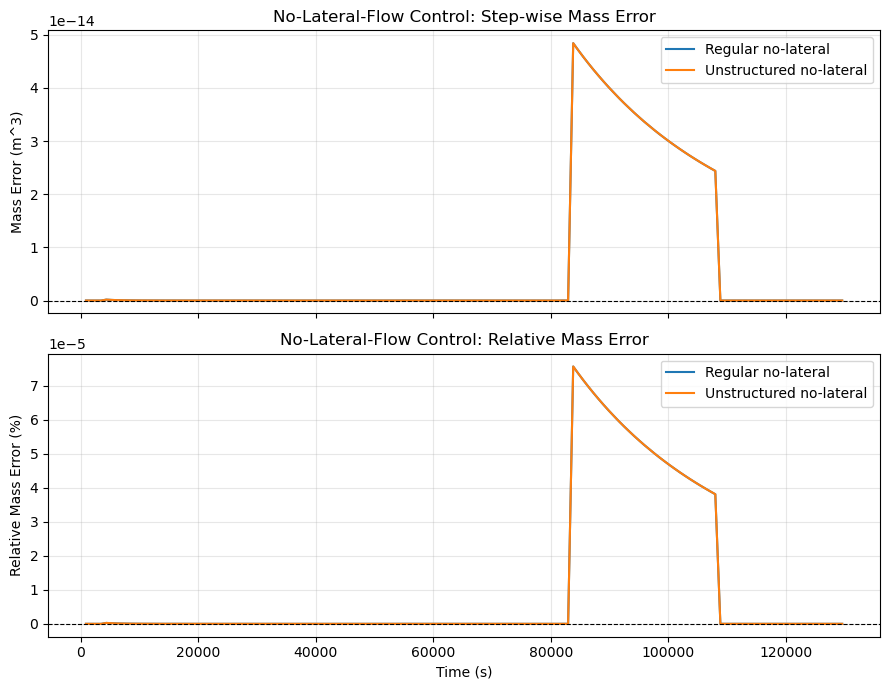

In [15]:
def zero_lateral_widths(widths_dict):
    zeroed = {}
    for prism, row in widths_dict.items():
        zeroed[prism] = [0.0 for _ in row]
    return zeroed


reg_grid_solver_vertical_only = RichardsSolver(
    alpha=shared_soil['alpha'],
    n_vg=shared_soil['n_vg'],
    theta_r=np.full((n_prisms_reg, shared_domain['n_layers']), shared_soil['theta_r']),
    theta_s=np.full((n_prisms_reg, shared_domain['n_layers']), shared_soil['theta_s']),
    Ks=np.full((n_prisms_reg, shared_domain['n_layers']), shared_soil['Ks']),
    S_s=shared_soil['S_s'],
    dz=shared_domain['dz'],
    base_elevations=np.full(n_prisms_reg, shared_domain['base_elevation']),
    rainfall_intensity=shared_rainfall['intensity'],
    rainfall_prisms=shared_rainfall['regular_prisms'],
    adj_prisms=adj_reg,
    A_ij=areas_reg,
    W_ij=zero_lateral_widths(widths_reg),
    L_ij=lengths_reg,
)

uns_grid_solver_vertical_only = RichardsSolver(
    alpha=shared_soil['alpha'],
    n_vg=shared_soil['n_vg'],
    theta_r=np.full((n_prisms_uns, shared_domain['n_layers']), shared_soil['theta_r']),
    theta_s=np.full((n_prisms_uns, shared_domain['n_layers']), shared_soil['theta_s']),
    Ks=np.full((n_prisms_uns, shared_domain['n_layers']), shared_soil['Ks']),
    S_s=shared_soil['S_s'],
    dz=shared_domain['dz'],
    base_elevations=np.full(n_prisms_uns, shared_domain['base_elevation']),
    rainfall_intensity=shared_rainfall['intensity'],
    rainfall_prisms=shared_rainfall['unstructured_prisms'],
    adj_prisms=adj_uns,
    A_ij=areas_uns,
    W_ij=zero_lateral_widths(widths_uns),
    L_ij=lengths_uns,
)

reg_metrics_vertical_only = run_experiment_metrics(reg_grid_solver_vertical_only, shared_time['dt'], shared_time['steps'])
uns_metrics_vertical_only = run_experiment_metrics(uns_grid_solver_vertical_only, shared_time['dt'], shared_time['steps'])

print(f"{'Metric':<34} | {'Reg full':>14} | {'Reg no-lat':>14} | {'Uns full':>14} | {'Uns no-lat':>14}")
print('-' * 100)
for key in metric_keys:
    print(
        f"{key:<34} | {reg_metrics[key]:>14.6e} | {reg_metrics_vertical_only[key]:>14.6e} | "
        f"{uns_metrics[key]:>14.6e} | {uns_metrics_vertical_only[key]:>14.6e}"
    )

tr_v, err_r_v, rel_r_v = mass_error_time_series(reg_grid_solver_vertical_only, shared_time['dt'], shared_time['steps'])
tu_v, err_u_v, rel_u_v = mass_error_time_series(uns_grid_solver_vertical_only, shared_time['dt'], shared_time['steps'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
ax1.plot(tr_v, err_r_v, label='Regular no-lateral', color='tab:blue')
ax1.plot(tu_v, err_u_v, label='Unstructured no-lateral', color='tab:orange')
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax1.set_ylabel('Mass Error (m^3)')
ax1.set_title('No-Lateral-Flow Control: Step-wise Mass Error')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(tr_v, rel_r_v, label='Regular no-lateral', color='tab:blue')
ax2.plot(tu_v, rel_u_v, label='Unstructured no-lateral', color='tab:orange')
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Relative Mass Error (%)')
ax2.set_title('No-Lateral-Flow Control: Relative Mass Error')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

## Lateral-Only Diagnostic by Depth

This section isolates horizontal exchange and compares the cumulative lateral exchange in each vertical layer for the full-flow cases.

   Layer |   Depth center (m) |    Regular lat exch (m3) |    Unstructured lat exch (m3)
--------------------------------------------------------------------------------------------
       0 |       2.000000e-02 |             1.252934e-13 |                  7.102806e-14
       1 |       6.000000e-02 |             6.261359e-12 |                  3.556045e-12
       2 |       1.000000e-01 |             2.658234e-10 |                  1.513509e-10
       3 |       1.400000e-01 |             9.095232e-09 |                  5.140613e-09
       4 |       1.800000e-01 |             2.905565e-07 |                  9.512641e-08


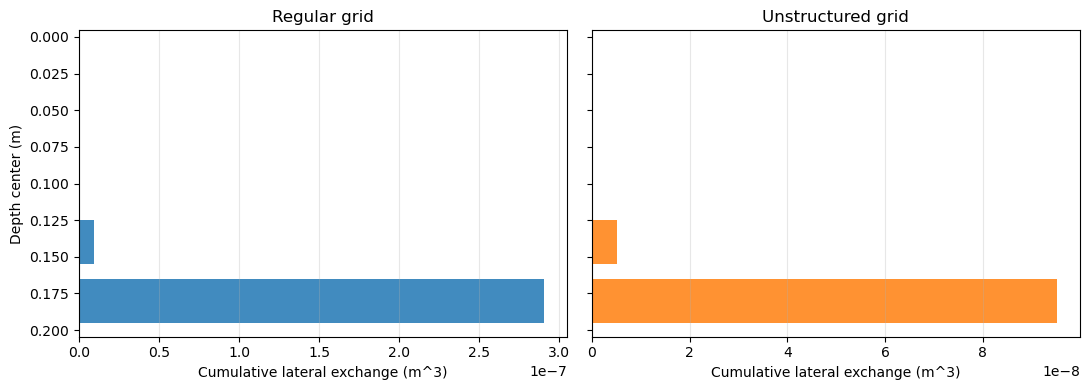

In [16]:
def per_layer_lateral_exchange_profile(solver, dt, steps, h0_value=-10.0):
    h = np.full(solver.total_cells, h0_value)
    cumulative_by_layer = np.zeros(solver.n_layers)

    for _ in range(steps):
        h = solver.solve_step(h, dt)
        _ensure_Z(solver)
        for layer in range(solver.n_layers):
            layer_fluxes = solver.get_lateral_fluxes(h, layer=layer)
            cumulative_by_layer[layer] += sum(abs(q) for q in layer_fluxes.values()) * dt

    return cumulative_by_layer


lat_profile_reg = per_layer_lateral_exchange_profile(reg_grid_solver, shared_time['dt'], shared_time['steps'])
lat_profile_uns = per_layer_lateral_exchange_profile(uns_grid_solver, shared_time['dt'], shared_time['steps'])
layer_centers = np.cumsum(shared_domain['dz']) - 0.5 * shared_domain['dz']

print(f"{'Layer':>8} | {'Depth center (m)':>18} | {'Regular lat exch (m3)':>24} | {'Unstructured lat exch (m3)':>29}")
print('-' * 92)
for layer in range(shared_domain['n_layers']):
    print(
        f"{layer:>8d} | {layer_centers[layer]:>18.6e} | {lat_profile_reg[layer]:>24.6e} | {lat_profile_uns[layer]:>29.6e}"
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
ax1.barh(layer_centers, lat_profile_reg, height=0.03, color='tab:blue', alpha=0.85)
ax1.invert_yaxis()
ax1.set_xlabel('Cumulative lateral exchange (m^3)')
ax1.set_ylabel('Depth center (m)')
ax1.set_title('Regular grid')
ax1.grid(True, axis='x', alpha=0.3)

ax2.barh(layer_centers, lat_profile_uns, height=0.03, color='tab:orange', alpha=0.85)
ax2.set_xlabel('Cumulative lateral exchange (m^3)')
ax2.set_title('Unstructured grid')
ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Log-Log Convergence Rate for the Δt Study

This section plots mass-balance error against time step on log-log axes and estimates the local slope between successive refinements.

Refinement pair    |  Regular slope |   Unstructured slope
------------------------------------------------------------
864->432           |       0.514554 |             0.770575
432->216           |       1.445110 |             1.494815
216->108           |       1.586938 |             1.587078


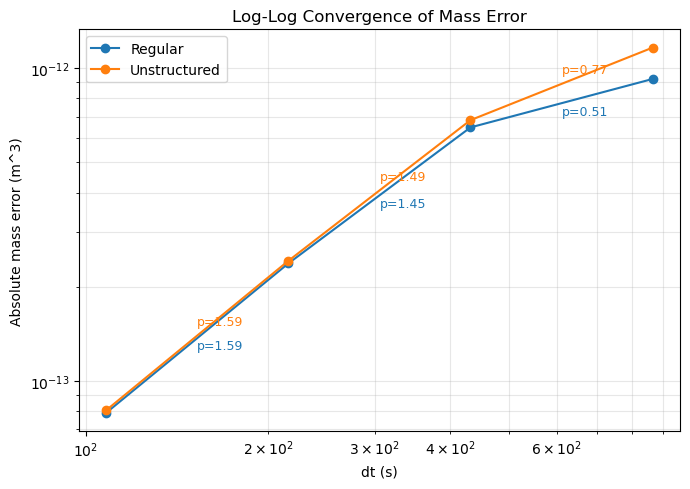

In [17]:
dt_array = np.array([row['dt'] for row in refinement_results], dtype=float)
reg_err_array = np.abs(np.array([row['reg_mass_error'] for row in refinement_results], dtype=float))
uns_err_array = np.abs(np.array([row['uns_mass_error'] for row in refinement_results], dtype=float))

reg_orders = np.log(reg_err_array[:-1] / reg_err_array[1:]) / np.log(dt_array[:-1] / dt_array[1:])
uns_orders = np.log(uns_err_array[:-1] / uns_err_array[1:]) / np.log(dt_array[:-1] / dt_array[1:])

print(f"{'Refinement pair':<18} | {'Regular slope':>14} | {'Unstructured slope':>20}")
print('-' * 60)
for i in range(len(dt_array) - 1):
    pair = f"{int(dt_array[i])}->{int(dt_array[i+1])}"
    print(f"{pair:<18} | {reg_orders[i]:>14.6f} | {uns_orders[i]:>20.6f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(dt_array, reg_err_array, marker='o', label='Regular', color='tab:blue')
ax.loglog(dt_array, uns_err_array, marker='o', label='Unstructured', color='tab:orange')

for i in range(len(dt_array) - 1):
    x_mid = np.sqrt(dt_array[i] * dt_array[i + 1])
    y_mid_reg = np.sqrt(reg_err_array[i] * reg_err_array[i + 1])
    y_mid_uns = np.sqrt(uns_err_array[i] * uns_err_array[i + 1])
    ax.text(x_mid, y_mid_reg * 0.92, f"p={reg_orders[i]:.2f}", color='tab:blue', fontsize=9)
    ax.text(x_mid, y_mid_uns * 1.08, f"p={uns_orders[i]:.2f}", color='tab:orange', fontsize=9)

ax.set_xlabel('dt (s)')
ax.set_ylabel('Absolute mass error (m^3)')
ax.set_title('Log-Log Convergence of Mass Error')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Full vs No-Lateral Budget Decomposition

This section puts the full-flow and no-lateral diagnostics next to each other for each grid, so the budget contribution of lateral exchange is visually explicit.

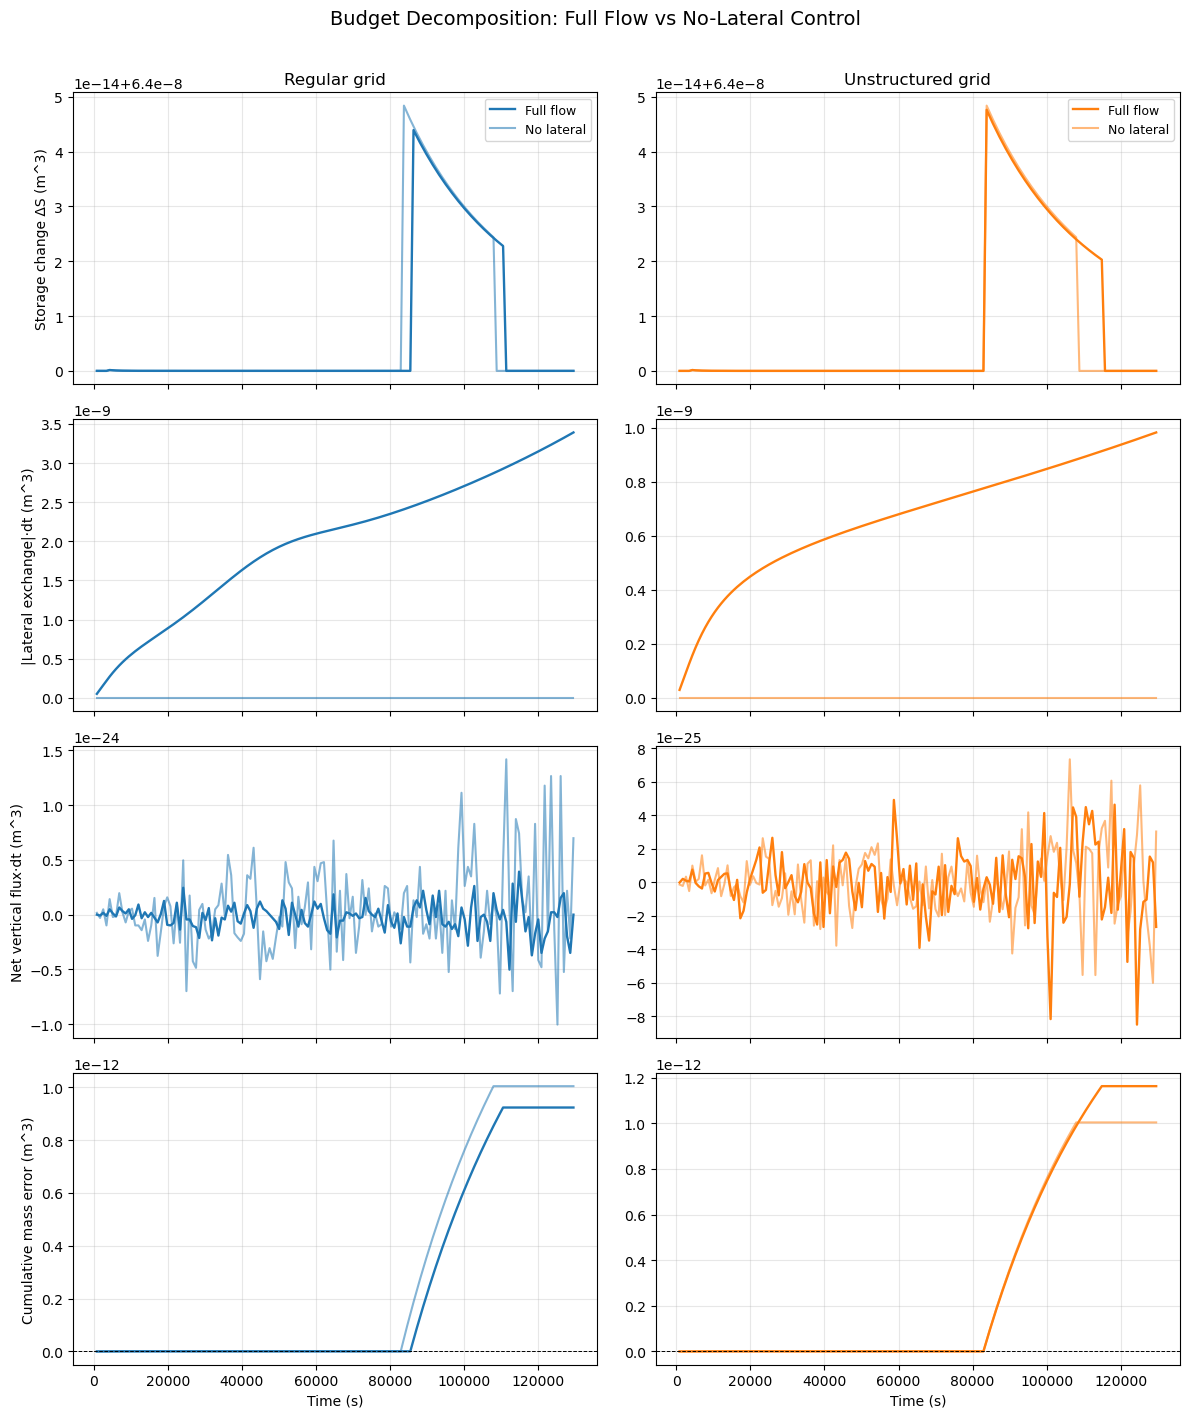

In [19]:
bd_r_vertical_only = run_budget_diagnostics(reg_grid_solver_vertical_only, shared_time['dt'], shared_time['steps'])
bd_u_vertical_only = run_budget_diagnostics(uns_grid_solver_vertical_only, shared_time['dt'], shared_time['steps'])

grid_panels = [
    ('Regular grid', bd_r, bd_r_vertical_only, 'tab:blue'),
    ('Unstructured grid', bd_u, bd_u_vertical_only, 'tab:orange'),
]
plot_keys = [
    ('dS', 'Storage change ΔS (m^3)'),
    ('lat_exchange', '|Lateral exchange|·dt (m^3)'),
    ('vert_net_in', 'Net vertical flux·dt (m^3)'),
    ('cum_error', 'Cumulative mass error (m^3)'),
]

fig, axes = plt.subplots(4, 2, figsize=(12, 14), sharex='col')
for col_idx, (grid_title, full_data, no_lat_data, color) in enumerate(grid_panels):
    for row_idx, (key, ylabel) in enumerate(plot_keys):
        ax = axes[row_idx, col_idx]
        ax.plot(full_data['times'], full_data[key], color=color, linewidth=1.7, label='Full flow')
        ax.plot(no_lat_data['times'], no_lat_data[key], color=color, linewidth=1.5, alpha=0.55, label='No lateral')
        if key == 'cum_error':
            ax.axhline(0, color='black', linestyle='--', linewidth=0.7)
        ax.grid(True, alpha=0.3)
        if col_idx == 0:
            ax.set_ylabel(ylabel)
        if row_idx == 0:
            ax.set_title(grid_title)
            ax.legend(loc='upper right', fontsize=9)
        if row_idx == len(plot_keys) - 1:
            ax.set_xlabel('Time (s)')

fig.suptitle('Budget Decomposition: Full Flow vs No-Lateral Control', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## Total Water Content and Hydraulic Head Time Series

This section compares the two grids at each time step using:
- Total water content (domain water storage, m^3)
- Mean hydraulic head across all cells (m)

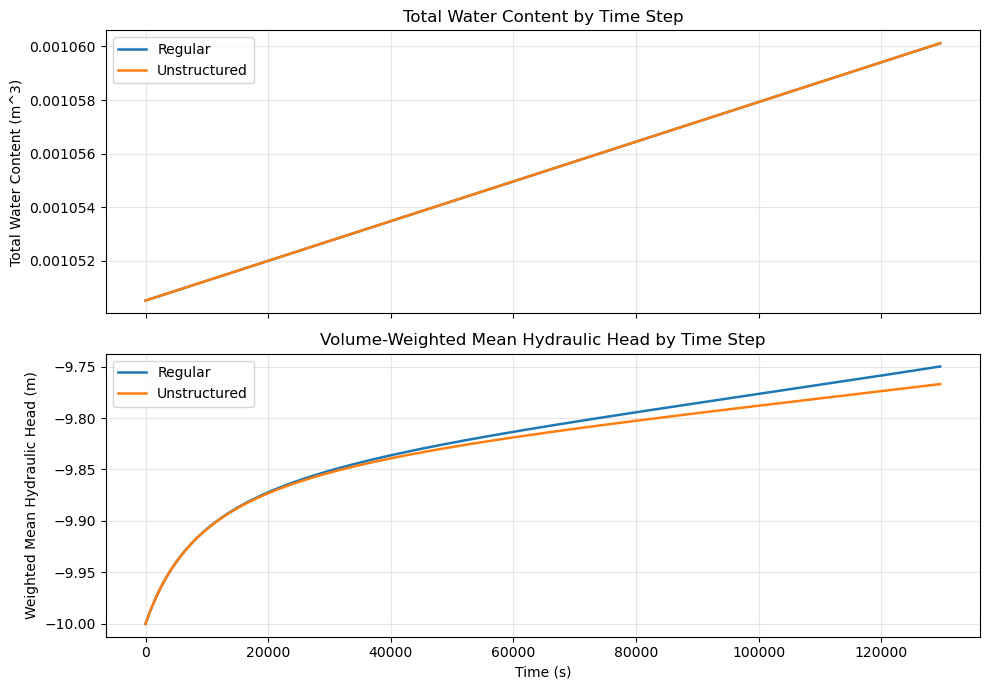

Final total water content (Regular):      1.060122e-03 m^3
Final total water content (Unstructured): 1.060122e-03 m^3
Final weighted mean head (Regular):       -9.749912e+00 m
Final weighted mean head (Unstructured):  -9.767007e+00 m


In [22]:
def get_cell_volumes(solver):
    volumes = np.zeros(solver.total_cells)
    for k in range(solver.n_layers):
        for i in range(solver.n_prisms):
            idx = k * solver.n_prisms + i
            volumes[idx] = solver.A_ij[i] * solver.dz[k]
    return volumes


def water_content_and_head_series(solver, dt, steps, h0_value=-10.0):
    h = np.full(solver.total_cells, h0_value)
    cell_volumes = get_cell_volumes(solver)

    times = np.zeros(steps + 1)
    storage = np.zeros(steps + 1)
    weighted_mean_head = np.zeros(steps + 1)

    storage[0] = solver.calculate_storage(h)
    weighted_mean_head[0] = np.average(h, weights=cell_volumes)

    for t in range(1, steps + 1):
        h = solver.solve_step(h, dt)
        times[t] = t * dt
        storage[t] = solver.calculate_storage(h)
        weighted_mean_head[t] = np.average(h, weights=cell_volumes)

    return times, storage, weighted_mean_head


# Use shared comparison settings
t_wc, storage_reg, head_reg = water_content_and_head_series(
    reg_grid_solver, shared_time['dt'], shared_time['steps']
)
_, storage_uns, head_uns = water_content_and_head_series(
    uns_grid_solver, shared_time['dt'], shared_time['steps']
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.plot(t_wc, storage_reg, label='Regular', color='tab:blue', linewidth=1.8)
ax1.plot(t_wc, storage_uns, label='Unstructured', color='tab:orange', linewidth=1.8)
ax1.set_ylabel('Total Water Content (m^3)')
ax1.set_title('Total Water Content by Time Step')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(t_wc, head_reg, label='Regular', color='tab:blue', linewidth=1.8)
ax2.plot(t_wc, head_uns, label='Unstructured', color='tab:orange', linewidth=1.8)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Weighted Mean Hydraulic Head (m)')
ax2.set_title('Volume-Weighted Mean Hydraulic Head by Time Step')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Final total water content (Regular):      {storage_reg[-1]:.6e} m^3")
print(f"Final total water content (Unstructured): {storage_uns[-1]:.6e} m^3")
print(f"Final weighted mean head (Regular):       {head_reg[-1]:.6e} m")
print(f"Final weighted mean head (Unstructured):  {head_uns[-1]:.6e} m")

## Unsaturated-to-Saturated Transition and Lateral-Flow Activation

This section tracks, for both grids:
- Saturated fraction in each layer over time (cells with h >= 0)
- Lateral exchange by layer and total lateral exchange

Activation time is defined as the first time the total lateral exchange reaches at least 0.1% of its run maximum.

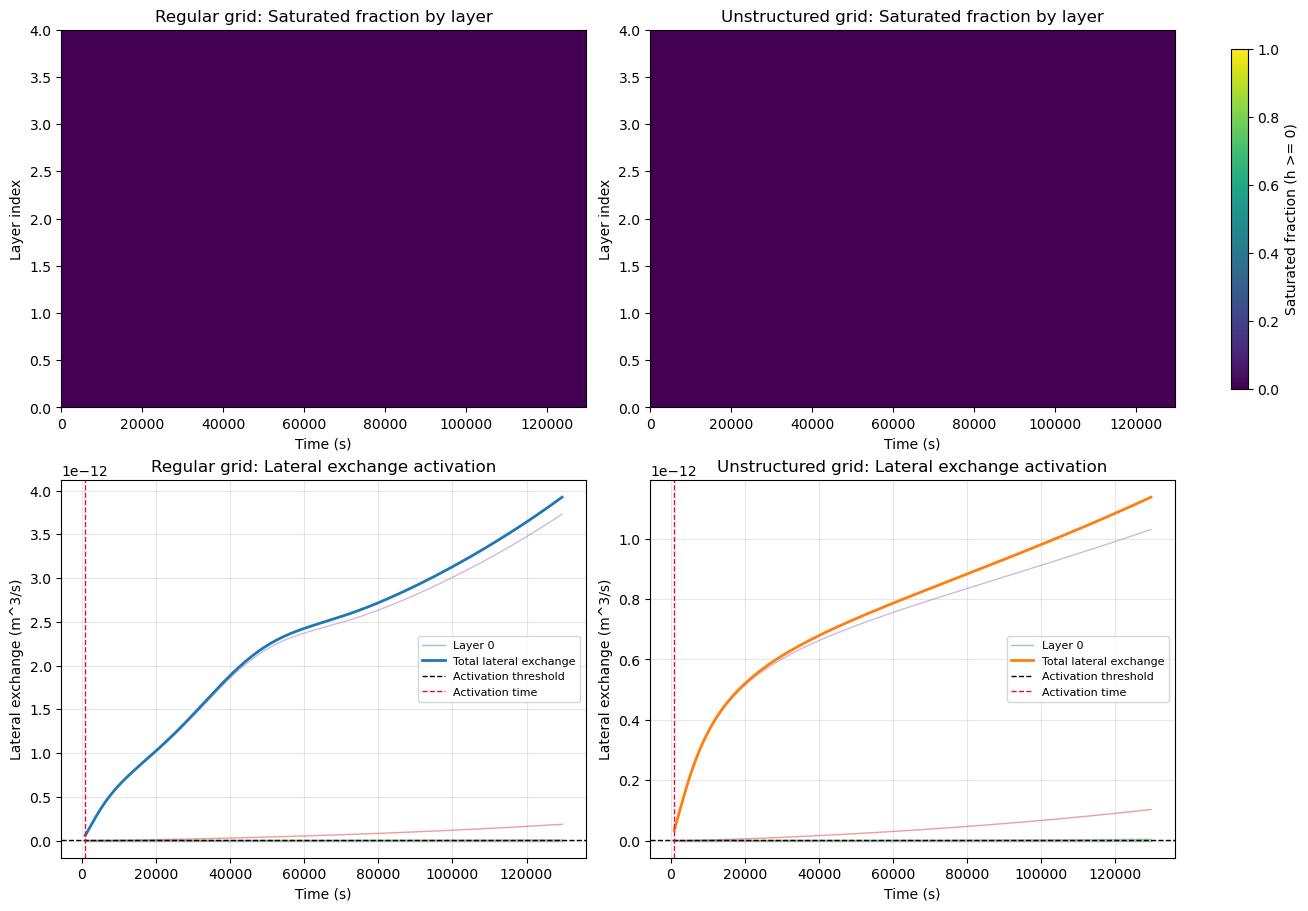

Regular lateral activation time:      864.0 s
Unstructured lateral activation time: 864.0 s


In [23]:
def transition_lateral_diagnostics(solver, dt, steps, h0_value=-10.0):
    h = np.full(solver.total_cells, h0_value)
    nL, nP = solver.n_layers, solver.n_prisms

    sat_fraction = np.zeros((nL, steps + 1))
    lat_by_layer = np.zeros((steps, nL))
    lat_total = np.zeros(steps)

    sat_fraction[:, 0] = (h.reshape(nL, nP) >= 0.0).mean(axis=1)

    for t in range(1, steps + 1):
        h = solver.solve_step(h, dt)
        h_layer = h.reshape(nL, nP)
        sat_fraction[:, t] = (h_layer >= 0.0).mean(axis=1)

        for layer in range(nL):
            layer_fluxes = solver.get_lateral_fluxes(h, layer=layer)
            lat_by_layer[t - 1, layer] = sum(abs(q) for q in layer_fluxes.values())

        lat_total[t - 1] = lat_by_layer[t - 1, :].sum()

    times_state = np.arange(steps + 1) * dt
    times_flux = np.arange(1, steps + 1) * dt

    max_lat = np.max(lat_total)
    threshold = 1e-3 * max_lat if max_lat > 0 else 0.0
    active_idx = np.where(lat_total >= threshold)[0]
    t_active = times_flux[active_idx[0]] if len(active_idx) > 0 else np.nan

    return {
        'times_state': times_state,
        'times_flux': times_flux,
        'sat_fraction': sat_fraction,
        'lat_by_layer': lat_by_layer,
        'lat_total': lat_total,
        'lat_activation_threshold': threshold,
        'lat_activation_time': t_active,
    }


diag_reg = transition_lateral_diagnostics(reg_grid_solver, shared_time['dt'], shared_time['steps'])
diag_uns = transition_lateral_diagnostics(uns_grid_solver, shared_time['dt'], shared_time['steps'])

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

# --- Top row: saturation transition heatmaps ---
for ax, diag, title in [
    (axes[0, 0], diag_reg, 'Regular grid: Saturated fraction by layer'),
    (axes[0, 1], diag_uns, 'Unstructured grid: Saturated fraction by layer'),
]:
    im = ax.imshow(
        diag['sat_fraction'],
        aspect='auto',
        origin='lower',
        extent=[diag['times_state'][0], diag['times_state'][-1], 0, reg_grid_solver.n_layers - 1],
        vmin=0.0,
        vmax=1.0,
        cmap='viridis',
    )
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Layer index')

cbar = fig.colorbar(im, ax=axes[0, :], location='right', shrink=0.9)
cbar.set_label('Saturated fraction (h >= 0)')

# --- Bottom row: lateral exchange activation ---
for ax, diag, title, color in [
    (axes[1, 0], diag_reg, 'Regular grid: Lateral exchange activation', 'tab:blue'),
    (axes[1, 1], diag_uns, 'Unstructured grid: Lateral exchange activation', 'tab:orange'),
]:
    n_layers = diag['lat_by_layer'].shape[1]
    for k in range(n_layers):
        ax.plot(diag['times_flux'], diag['lat_by_layer'][:, k], linewidth=1.0, alpha=0.45, label=f'Layer {k}' if k == 0 else None)

    ax.plot(diag['times_flux'], diag['lat_total'], color=color, linewidth=2.0, label='Total lateral exchange')
    ax.axhline(diag['lat_activation_threshold'], color='black', linestyle='--', linewidth=1.0, label='Activation threshold')
    if np.isfinite(diag['lat_activation_time']):
        ax.axvline(diag['lat_activation_time'], color='crimson', linestyle='--', linewidth=1.0, label='Activation time')

    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Lateral exchange (m^3/s)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.show()

print(f"Regular lateral activation time:      {diag_reg['lat_activation_time']:.1f} s")
print(f"Unstructured lateral activation time: {diag_uns['lat_activation_time']:.1f} s")